In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import os

In [2]:
#Configuration
#Jupyter compatibility
try:
    from IPython.display import display, Image
    JUPYTER = True
except ImportError:
    JUPYTER = False
 
# Matplotlib settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100 if JUPYTER else 300
plt.rcParams['savefig.dpi'] = 300
 
# Output directory
OUTPUT_DIR = 'architecture_diagram'

In [5]:
#Color scheme
COLOR_SCHEMES = {
    'warm_coral': {
        'name': 'Warm Coral',
        'description': 'Modern engaging style - Eye-catching for presentations',
        'input': '#943126',
        'conv': '#e74c3c',
        'lstm': '#f39c12',
        'transformer': '#8e44ad',
        'pool': "#c46862",
        'output': '#1c2833',
        'arrow': '#95a5a6',
        'bg_cnn': '#fadbd8',
        'bg_lstm': '#fef5e7',
        'bg_trans': '#f4ecf7',
    },       

}

In [6]:
#Helper functions for diagram creation
def create_output_dir():
    """Create output directory if it doesn't exist"""
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
        print(f"Created directory: {OUTPUT_DIR}/")
 
 
def create_professional_box(ax, x, y, width, height, text, color, 
                            edge_color='#2c3e50', textcolor='white', 
                            fontsize=9, shadow=True):
    """Create professional box with optional shadow"""
    
    if shadow:
        shadow_box = FancyBboxPatch(
            (x - width/2 + 0.03, y - height/2 - 0.03), width, height,
            boxstyle="round,pad=0.08", 
            edgecolor='none', 
            facecolor='#00000020',
            linewidth=0,
            zorder=1
        )
        ax.add_patch(shadow_box)
    
    box = FancyBboxPatch(
        (x - width/2, y - height/2), width, height,
        boxstyle="round,pad=0.08", 
        edgecolor=edge_color, 
        facecolor=color,
        linewidth=2,
        zorder=3
    )
    ax.add_patch(box)
    
    ax.text(x, y, text, ha='center', va='center', 
            color=textcolor, fontsize=fontsize, weight='bold', 
            zorder=4, linespacing=1.3)
    
    return {'left': x - width/2, 'right': x + width/2, 'center_y': y}
 
 
def create_elegant_arrow(ax, x1, y1, x2, y2, color='#95a5a6'):
    """Create elegant arrow"""
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle='->,head_width=0.35,head_length=0.35',
        color=color,
        linewidth=2.5,
        zorder=2,
        alpha=0.8
    )
    ax.add_patch(arrow)
 
 
def add_section_label(ax, x, y, text, color):
    """Add section label with border"""
    ax.text(x, y, text, ha='center', fontsize=11, 
            weight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.6', 
                     facecolor='white',
                     edgecolor=color,
                     linewidth=2,
                     alpha=0.95),
            zorder=5)

In [7]:
#Resnet
def create_resnet1d(colors, scheme_name):
    """Create ResNet1D architecture diagram"""
    
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.set_xlim(-0.5, 15.5)
    ax.set_ylim(0, 7)
    ax.axis('off')
    
    # Title
    ax.text(7.5, 6.5, 'ResNet1D Architecture', 
            ha='center', fontsize=18, weight='bold', color='#2c3e50')
    ax.plot([3, 12], [6.2, 6.2], 'k-', linewidth=2, alpha=0.2)
    
    y = 3.5
    boxes = {}
    
    # Input
    boxes['input'] = create_professional_box(
        ax, 0.8, y, 1.3, 1.6,
        'Input\n\n12-lead ECG\n12 × 1000',
        colors['input'], fontsize=8
    )
    
    # Initial Conv Block
    init_x = 2.5
    rect = mpatches.Rectangle(
        (init_x - 0.8, y - 1.5), 1.6, 3.0,
        facecolor=colors['bg_cnn'], 
        edgecolor='none',
        alpha=0.3,
        zorder=0
    )
    ax.add_patch(rect)
    
    add_section_label(ax, init_x, y + 1.8, 'Initial', colors['conv'])
    
    create_professional_box(ax, init_x, y + 0.6, 1.1, 0.35, 
                           'Conv1D', colors['conv'], fontsize=8, shadow=False)
    create_professional_box(ax, init_x, y + 0.15, 1.1, 0.35,
                           'BatchNorm', colors['conv'], fontsize=8, shadow=False)
    create_professional_box(ax, init_x, y - 0.3, 1.1, 0.35,
                           'ReLU', colors['conv'], fontsize=8, shadow=False)
    create_professional_box(ax, init_x, y - 0.75, 1.1, 0.35,
                           'MaxPool', colors['conv'], fontsize=8, shadow=False)
    
    boxes['init'] = {'left': init_x - 0.8, 'right': init_x + 0.8, 'center_y': y}
    
    create_elegant_arrow(ax, boxes['input']['right'], y, boxes['init']['left'], y, colors['arrow'])
    
    # Residual Blocks
    res_positions = [4.5, 6.5, 8.5, 10.5]
    res_labels = ['Block 1', 'Block 2', 'Block 3', 'Block 4']
    res_dims = ['64→128', '128→256', '256→512', '512→512']
    
    prev_box = boxes['init']
    
    for idx, (x_pos, label, dims) in enumerate(zip(res_positions, res_labels, res_dims)):
        
        rect = mpatches.FancyBboxPatch(
            (x_pos - 0.75, y - 1.2), 1.5, 2.4,
            boxstyle="round,pad=0.12", 
            edgecolor=colors['conv'],
            facecolor=colors['bg_cnn'],
            linewidth=1.5,
            linestyle='--',
            alpha=0.4,
            zorder=1
        )
        ax.add_patch(rect)
        
        ax.text(x_pos, y + 1.05, f'Residual {label}', 
                ha='center', fontsize=9, weight='bold',
                color=colors['conv'])
        
        create_professional_box(ax, x_pos, y + 0.35, 1.25, 0.38,
                               'Conv1D', colors['conv'], fontsize=8, shadow=False)
        create_professional_box(ax, x_pos, y - 0.1, 1.25, 0.38,
                               'BatchNorm', colors['conv'], fontsize=8, shadow=False)
        
        # Skip connection
        ax.plot([x_pos - 0.65, x_pos + 0.65], [y - 0.55, y - 0.55],
               color=colors['conv'], linewidth=2.5, alpha=0.6, zorder=2)
        ax.text(x_pos, y - 0.55, '+ Skip', ha='center', va='center',
               fontsize=7, weight='bold', color='white',
               bbox=dict(boxstyle='round,pad=0.2', 
                        facecolor=colors['conv'], alpha=0.8))
        
        ax.text(x_pos, y - 1.45, dims, ha='center',
               fontsize=8, style='italic', weight='bold',
               color=colors['conv'], alpha=0.7)
        
        boxes[f'res{idx}'] = {'left': x_pos - 0.75, 'right': x_pos + 0.75, 'center_y': y}
        
        create_elegant_arrow(ax, prev_box['right'], y, boxes[f'res{idx}']['left'], y, colors['arrow'])
        prev_box = boxes[f'res{idx}']
    
    # Global Pooling
    pool_x = 12.5
    boxes['pool'] = create_professional_box(
        ax, pool_x, y, 1.3, 1.1,
        'Global\nPooling',
        colors['pool'], fontsize=9
    )
    boxes['pool'] = {'left': pool_x - 0.65, 'right': pool_x + 0.65, 'center_y': y}
    
    create_elegant_arrow(ax, prev_box['right'], y, boxes['pool']['left'], y, colors['arrow'])
    
    # Output
    out_x = 14.5
    create_professional_box(ax, out_x, y, 1.3, 1.2,
                           'Classifier\n\n8 Classes',
                           colors['output'], fontsize=8)
    
    create_elegant_arrow(ax, boxes['pool']['right'], y, out_x - 0.65, y, colors['arrow'])
    
    # Save
    plt.tight_layout()
    filename = f'{OUTPUT_DIR}/{scheme_name}_resnet1d.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    
    if JUPYTER:
        plt.show()
    else:
        plt.close()
    
    return filename

In [8]:
#xlstm
def create_xlstm(colors, scheme_name):
    """Create xLSTM architecture diagram"""
    
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.set_xlim(-0.5, 14.5)
    ax.set_ylim(0, 7)
    ax.axis('off')
    
    # Title
    ax.text(7, 6.5, 'xLSTM Architecture', 
            ha='center', fontsize=18, weight='bold', color='#2c3e50')
    ax.plot([2.5, 11.5], [6.2, 6.2], 'k-', linewidth=2, alpha=0.2)
    
    y = 3.5
    boxes = {}
    
    # Input
    boxes['input'] = create_professional_box(
        ax, 0.8, y, 1.3, 1.6,
        'Input\n\n12-lead ECG\n12 × 1000',
        colors['input'], fontsize=8
    )
    
    # Projection
    emb_x = 2.5
    boxes['emb'] = create_professional_box(
        ax, emb_x, y, 1.5, 0.9,
        'Linear\nProjection\n12→128',
        colors['conv'], fontsize=8
    )
    boxes['emb'] = {'left': emb_x - 0.75, 'right': emb_x + 0.75, 'center_y': y}
    
    create_elegant_arrow(ax, boxes['input']['right'], y, boxes['emb']['left'], y, colors['arrow'])
    
    # BiLSTM Layers
    lstm_positions = [5.5, 9.5]
    lstm_labels = ['BiLSTM Layer 1', 'BiLSTM Layer 2']
    lstm_dims = ['128', '256']
    
    prev_box = boxes['emb']
    
    for lstm_x, label, dim in zip(lstm_positions, lstm_labels, lstm_dims):
        
        # Background
        rect = mpatches.FancyBboxPatch(
            (lstm_x - 1.5, y - 1.6), 3.0, 3.2,
            boxstyle="round,pad=0.15", 
            edgecolor=colors['lstm'],
            facecolor=colors['bg_lstm'],
            linewidth=2,
            linestyle='--',
            alpha=0.4,
            zorder=0
        )
        ax.add_patch(rect)
        
        add_section_label(ax, lstm_x, y + 2.0, label, colors['lstm'])
        
        # Forward arrow
        ax.annotate('', xy=(lstm_x + 1.2, y + 0.4), xytext=(lstm_x - 1.2, y + 0.4),
                   arrowprops=dict(arrowstyle='->', lw=2, color=colors['lstm'], alpha=0.5))
        
        create_professional_box(ax, lstm_x, y + 0.4, 2.5, 0.5,
                               f'Forward LSTM ({dim})',
                               colors['lstm'], fontsize=8, shadow=False)
        
        # Backward arrow
        ax.annotate('', xy=(lstm_x - 1.2, y - 0.4), xytext=(lstm_x + 1.2, y - 0.4),
                   arrowprops=dict(arrowstyle='->', lw=2, color=colors['lstm'], alpha=0.5))
        
        create_professional_box(ax, lstm_x, y - 0.4, 2.5, 0.5,
                               f'Backward LSTM ({dim})',
                               colors['lstm'], fontsize=8, shadow=False)
        
        boxes[f'lstm{lstm_x}'] = {'left': lstm_x - 1.5, 'right': lstm_x + 1.5, 'center_y': y}
        
        create_elegant_arrow(ax, prev_box['right'], y, boxes[f'lstm{lstm_x}']['left'], y, colors['arrow'])
        prev_box = boxes[f'lstm{lstm_x}']
    
    # Dense + Output
    dense_x = 12.0
    boxes['dense'] = create_professional_box(
        ax, dense_x, y, 1.3, 0.9,
        'Dense\n+ Dropout',
        colors['pool'], fontsize=8
    )
    boxes['dense'] = {'left': dense_x - 0.65, 'right': dense_x + 0.65, 'center_y': y}
    
    create_elegant_arrow(ax, prev_box['right'], y, boxes['dense']['left'], y, colors['arrow'])
    
    out_x = 13.7
    create_professional_box(ax, out_x, y, 1.3, 1.2,
                           'Classifier\n\n8 Classes',
                           colors['output'], fontsize=8)
    
    create_elegant_arrow(ax, boxes['dense']['right'], y, out_x - 0.65, y, colors['arrow'])
    
    # Save
    plt.tight_layout()
    filename = f'{OUTPUT_DIR}/{scheme_name}_xlstm.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    
    if JUPYTER:
        plt.show()
    else:
        plt.close()
    
    return filename

In [9]:
#HybridCNN-Transformer
def create_hybrid(colors, scheme_name):
    """Create Hybrid CNN-Transformer diagram"""
    
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.set_xlim(-0.5, 15.5)
    ax.set_ylim(0, 7)
    ax.axis('off')
    
    # Title
    ax.text(7.5, 6.5, 'Hybrid CNN-Transformer Architecture', 
            ha='center', fontsize=18, weight='bold', color='#2c3e50')
    ax.plot([2, 13], [6.2, 6.2], 'k-', linewidth=2, alpha=0.2)
    
    y = 3.5
    boxes = {}
    
    # Input
    boxes['input'] = create_professional_box(
        ax, 0.8, y, 1.3, 1.6,
        'Input\n\n12-lead ECG\n12 × 1000',
        colors['input'], fontsize=8
    )
    
    # CNN Encoder
    cnn_positions = [2.5, 3.7, 4.9, 6.1]
    cnn_labels = ['Block 1', 'Block 2', 'Block 3', 'Block 4']
    cnn_dims = ['12→64', '64→128', '128→256', '256→512']
    
    # CNN Background
    rect = mpatches.FancyBboxPatch(
        (2.0, y - 1.8), 4.6, 3.6,
        boxstyle="round,pad=0.15", 
        edgecolor=colors['conv'],
        facecolor=colors['bg_cnn'],
        linewidth=2,
        linestyle='--',
        alpha=0.35,
        zorder=0
    )
    ax.add_patch(rect)
    
    add_section_label(ax, 4.3, y + 2.1, 'CNN Encoder', colors['conv'])
    
    prev_box = boxes['input']
    
    for x_pos, label, dims in zip(cnn_positions, cnn_labels, cnn_dims):
        
        # Block
        rect = mpatches.Rectangle(
            (x_pos - 0.5, y - 1.0), 1.0, 2.0,
            facecolor='white',
            edgecolor=colors['conv'],
            linewidth=1.5,
            alpha=0.6,
            zorder=1
        )
        ax.add_patch(rect)
        
        ax.text(x_pos, y + 0.85, label, ha='center',
               fontsize=8, weight='bold', color=colors['conv'])
        
        create_professional_box(ax, x_pos, y + 0.25, 0.85, 0.35,
                               'Conv', colors['conv'], fontsize=7, shadow=False)
        create_professional_box(ax, x_pos, y - 0.2, 0.85, 0.35,
                               'Skip', colors['conv'], fontsize=7, shadow=False)
        
        ax.text(x_pos, y - 1.25, dims, ha='center',
               fontsize=7, style='italic', weight='bold',
               color=colors['conv'], alpha=0.7)
        
        boxes[f'cnn{x_pos}'] = {'left': x_pos - 0.5, 'right': x_pos + 0.5, 'center_y': y}
        
        create_elegant_arrow(ax, prev_box['right'], y, boxes[f'cnn{x_pos}']['left'], y, colors['arrow'])
        prev_box = boxes[f'cnn{x_pos}']
    
    # Transformer
    trans_x = 8.3
    
    # Transformer Background
    rect = mpatches.FancyBboxPatch(
        (trans_x - 1.0, y - 1.8), 2.0, 3.6,
        boxstyle="round,pad=0.15", 
        edgecolor=colors['transformer'],
        facecolor=colors['bg_trans'],
        linewidth=2,
        linestyle='--',
        alpha=0.35,
        zorder=0
    )
    ax.add_patch(rect)
    
    add_section_label(ax, trans_x, y + 2.1, 'Transformer', colors['transformer'])
    
    create_professional_box(ax, trans_x, y + 0.55, 1.6, 0.48,
                           'Multi-Head\nAttention',
                           colors['transformer'], fontsize=7, shadow=False)
    create_professional_box(ax, trans_x, y + 0.0, 1.6, 0.4,
                           'Feed-Forward',
                           colors['transformer'], fontsize=7, shadow=False)
    create_professional_box(ax, trans_x, y - 0.5, 1.6, 0.35,
                           '× 6 Layers',
                           colors['transformer'], fontsize=7, shadow=False)
    
    boxes['trans'] = {'left': trans_x - 1.0, 'right': trans_x + 1.0, 'center_y': y}
    
    create_elegant_arrow(ax, prev_box['right'], y, boxes['trans']['left'], y, colors['arrow'])
    
    # Pooling
    pool_x = 11.0
    boxes['pool'] = create_professional_box(
        ax, pool_x, y, 1.3, 1.0,
        'Global\nPooling',
        colors['pool'], fontsize=8
    )
    boxes['pool'] = {'left': pool_x - 0.65, 'right': pool_x + 0.65, 'center_y': y}
    
    create_elegant_arrow(ax, boxes['trans']['right'], y, boxes['pool']['left'], y, colors['arrow'])
    
    # Linear Head
    lin_x = 12.8
    create_professional_box(ax, lin_x, y + 0.35, 1.0, 0.42,
                           'Linear', colors['output'], fontsize=7, shadow=False)
    create_professional_box(ax, lin_x, y - 0.1, 1.0, 0.38,
                           'GELU', colors['output'], fontsize=7, shadow=False)
    create_professional_box(ax, lin_x, y - 0.55, 1.0, 0.38,
                           '8 classes', colors['output'], fontsize=7, shadow=False)
    
    boxes['linear'] = {'left': lin_x - 0.5, 'right': lin_x + 0.5, 'center_y': y}
    
    create_elegant_arrow(ax, boxes['pool']['right'], y, boxes['linear']['left'], y, colors['arrow'])
    
    # Output
    out_x = 14.5
    create_professional_box(ax, out_x, y, 1.3, 1.2,
                           'Output\n\n8 Classes',
                           colors['input'], fontsize=8)
    
    create_elegant_arrow(ax, boxes['linear']['right'], y, out_x - 0.65, y, colors['arrow'])
    
    # Save
    plt.tight_layout()
    filename = f'{OUTPUT_DIR}/{scheme_name}_hybrid.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    
    if JUPYTER:
        plt.show()
    else:
        plt.close()
    
    return filename

ARCHITECTURE DIAGRAM GENERATOR
Color Schemes Available:
   1. Warm Coral: Modern engaging style - Eye-catching for presentations  WILL GENERATE


 Generating Warm Coral...


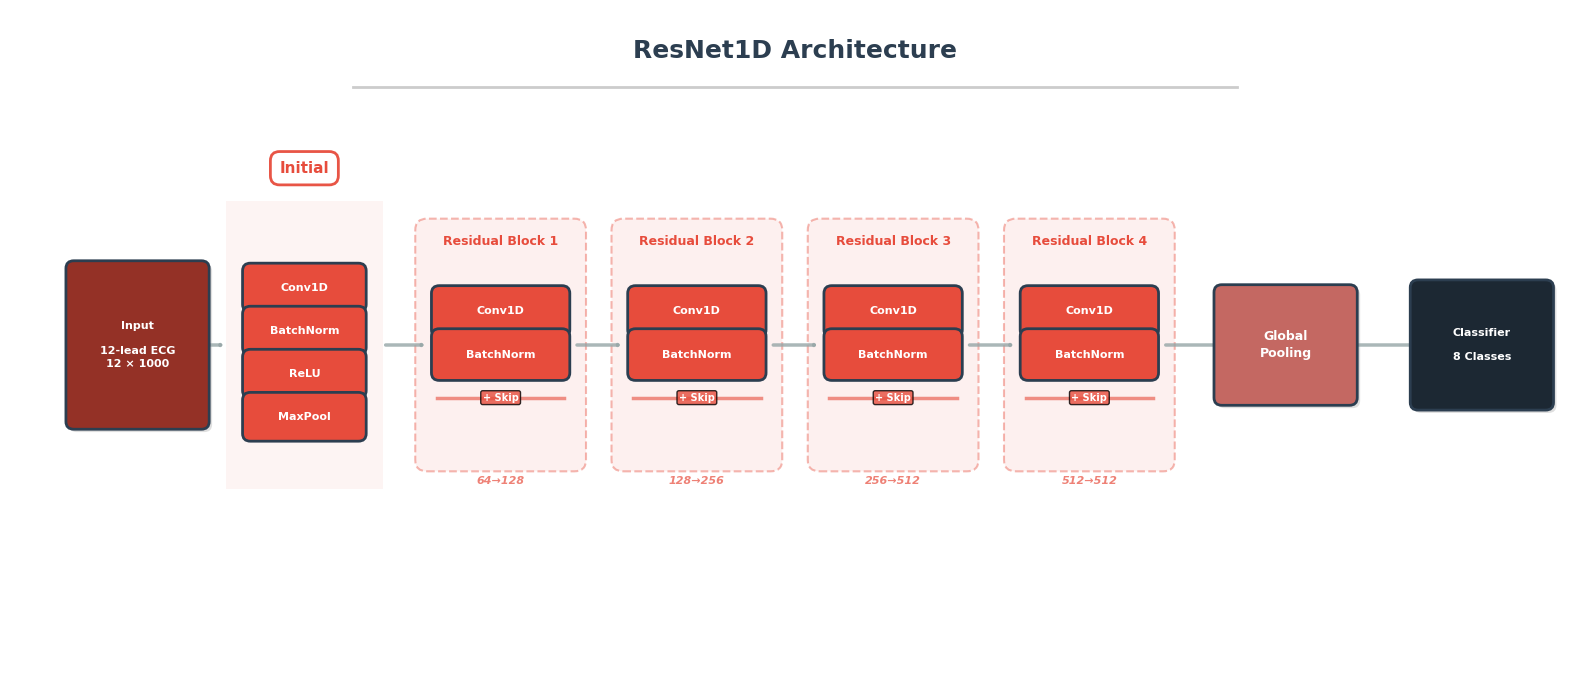

   ResNet1D:  architecture_diagram/warm_coral_resnet1d.png


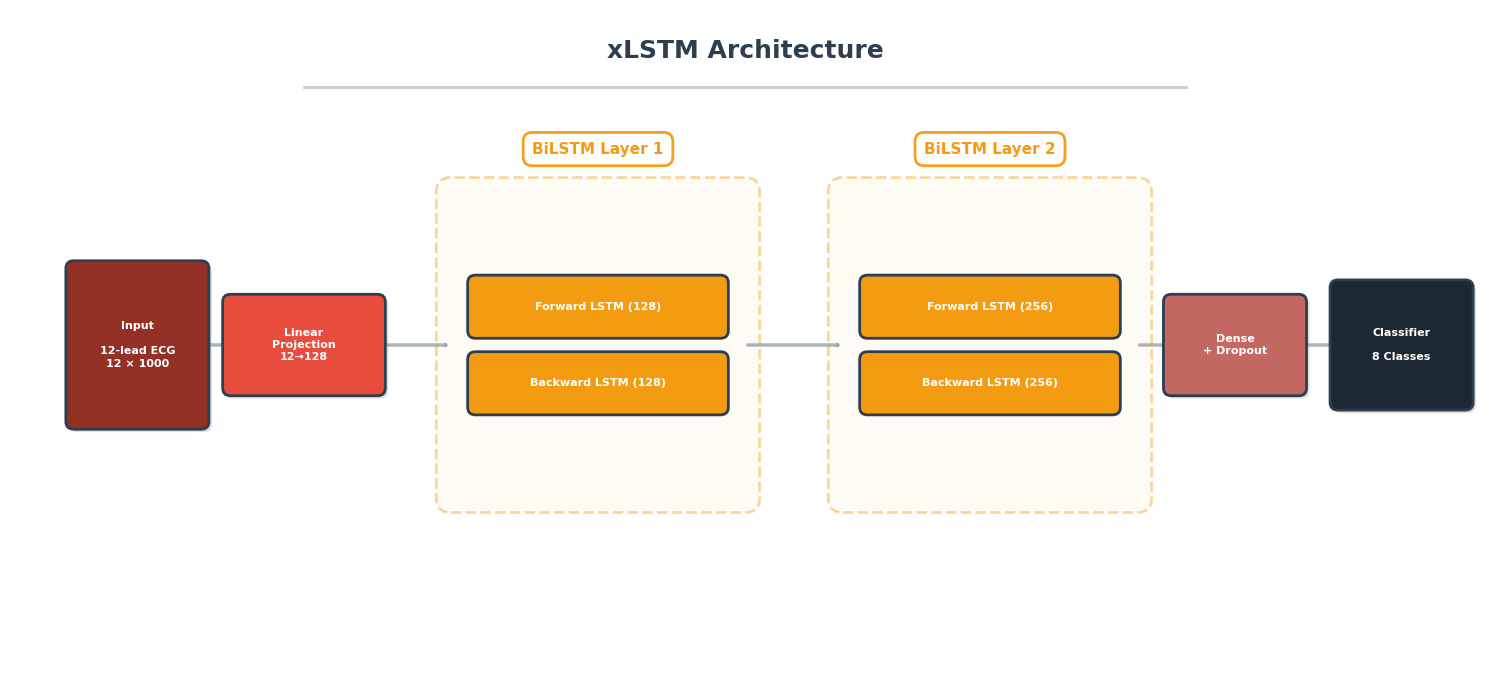

   xLSTM:     architecture_diagram/warm_coral_xlstm.png


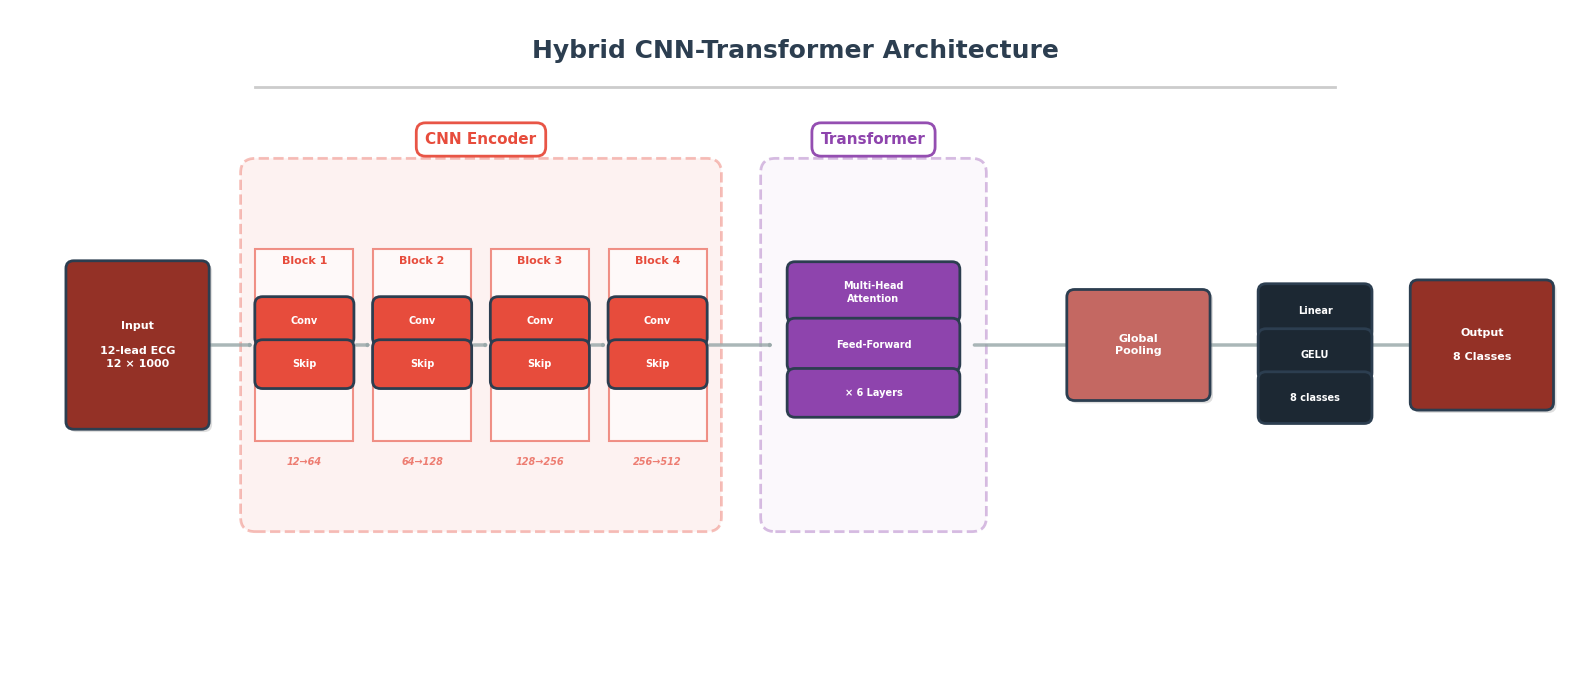

   Hybrid:    architecture_diagram/warm_coral_hybrid.png
Output Directory: architecture_diagram/
Total Files Generated: 3
Color Schemes: 1
Architectures per scheme: 3 (ResNet1D, xLSTM, Hybrid)

 Files created:

   warm_coral:
      • warm_coral_resnet1d.png
      • warm_coral_xlstm.png
      • warm_coral_hybrid.png


In [11]:
#Main function to create all diagrams
def generate_all_diagrams(schemes_to_generate='all'):
    """
    Generate all architecture diagrams
    
    Args:
        schemes_to_generate: 'all' or list of scheme names
                           e.g., ['academic_blue', 'nature_green']
    """
    
    create_output_dir()
    print("ARCHITECTURE DIAGRAM GENERATOR")
    
    # Determine which schemes to generate
    if schemes_to_generate == 'all':
        schemes = COLOR_SCHEMES
    else:
        schemes = {k: COLOR_SCHEMES[k] for k in schemes_to_generate if k in COLOR_SCHEMES}
    
    print("Color Schemes Available:")
    for i, (scheme_name, colors) in enumerate(COLOR_SCHEMES.items(), 1):
        status = " WILL GENERATE" if scheme_name in schemes else "  (skipped)"
        print(f"   {i}. {colors['name']}: {colors['description']} {status}")
    print()
    
    # Generate diagrams
    total_files = 0
    
    for scheme_name, colors in schemes.items():
        print(f"\n Generating {colors['name']}...")
        
        # Generate all 3 architectures
        f1 = create_resnet1d(colors, scheme_name)
        print(f"   ResNet1D:  {f1}")
        
        f2 = create_xlstm(colors, scheme_name)
        print(f"   xLSTM:     {f2}")
        
        f3 = create_hybrid(colors, scheme_name)
        print(f"   Hybrid:    {f3}")
        
        total_files += 3
    
    # Summary    
    print(f"Output Directory: {OUTPUT_DIR}/")
    print(f"Total Files Generated: {total_files}")
    print(f"Color Schemes: {len(schemes)}")
    print(f"Architectures per scheme: 3 (ResNet1D, xLSTM, Hybrid)")
    print()
    
    print(" Files created:")
    for scheme_name in schemes.keys():
        print(f"\n   {scheme_name}:")
        print(f"      • {scheme_name}_resnet1d.png")
        print(f"      • {scheme_name}_xlstm.png")
        print(f"      • {scheme_name}_hybrid.png")
    
 
 
# CONVENIENCE FUNCTIONS
 
def generate_recommended():
    """Generate only recommended schemes (Academic Blue + Nature Green)"""
    print(" Generating RECOMMENDED schemes for thesis...\n")
    generate_all_diagrams(['academic_blue', 'nature_green'])
 
 
def generate_single(scheme_name):
    """Generate diagrams for a single color scheme"""
    if scheme_name not in COLOR_SCHEMES:
        print(f" Error: '{scheme_name}' not found!")
        print(f"Available schemes: {list(COLOR_SCHEMES.keys())}")
        return
    
    print(f"\nGenerating {COLOR_SCHEMES[scheme_name]['name']} only...\n")
    generate_all_diagrams([scheme_name])
 
 
# MAIN EXECUTION
 
if __name__ == "__main__":
    # Generate ALL color schemes (15 files total)
    generate_all_diagrams('all')